# EDA - Klasifikasi Penggunaan Masker pada Wajah

Notebook ini diperluas agar sesuai dengan proposal: tidak hanya menghitung distribusi kelas, tetapi juga memeriksa kualitas citra, integritas data, outlier, duplikasi, dan verifikasi ROI wajah secara otomatis.

## 1. Setup

In [2]:
import sys
# Jika script diupload sebagai dataset Kaggle, hilangkan tanda pagar di bawah ini dan sesuaikan foldernya
# sys.path.append('/kaggle/input/datasets/emageeeee/pcd-k23')

from config import CLASSES
from src.preprocess import download_data_from_kaggle

from pathlib import Path
import hashlib
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageStat, UnidentifiedImageError
from src.eda import image_stats, file_sha1, show_sample_grid


pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
EXPECTED_SPLITS = ["Train", "Validation", "Test"]
EXPECTED_LABELS = CLASSES


## 2. Scan Dataset dan Metadata Dasar

In [3]:
DATA_DIR = download_data_from_kaggle()
print("Dataset path:", DATA_DIR.resolve())
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset tidak ditemukan di {DATA_DIR}")

records = []
corrupt_files = []

for split in EXPECTED_SPLITS:
    split_dir = DATA_DIR / split
    if not split_dir.exists():
        continue

    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        for path in sorted(class_dir.iterdir()):
            if path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            try:
                stats = image_stats(path)
                records.append({
                    "split": split,
                    "label": class_dir.name,
                    "filename": path.name,
                    "path": str(path),
                    **stats,
                })
            except (UnidentifiedImageError, OSError, ValueError) as exc:
                corrupt_files.append({"path": str(path), "error": repr(exc)})

files_df = pd.DataFrame(records)
print("Total gambar:", len(files_df))
print("File korup/tidak terbaca:", len(corrupt_files))
files_df.head()


Dataset path: C:\Users\hp\.cache\kagglehub\datasets\ashishjangra27\face-mask-12k-images-dataset\versions\1\Face Mask Dataset
Total gambar: 11792
File korup/tidak terbaca: 0


,split,label,filename,path,width,height,aspect_ratio,file_size_kb,mean_intensity,std_intensity,r_mean,g_mean,b_mean
0,Train,WithMask,10.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,82,82,1.0,16.145508,141.480815,57.516012,133.151844,145.779298,141.196014
1,Train,WithMask,100.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,25,25,1.0,1.744141,140.249600,76.533298,144.500800,137.704000,142.033600
2,Train,WithMask,1004.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,50,50,1.0,5.636719,68.369200,43.217831,81.588400,63.590000,58.336800
3,Train,WithMask,1005.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,53,53,1.0,6.521484,88.077608,49.689721,102.186899,81.723389,83.759701
4,Train,WithMask,1006.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,37,37,1.0,3.140625,91.395909,39.353369,103.939372,86.259313,84.912345


## 3. Distribusi Split dan Kelas

Bagian ini sesuai dengan proposal poin *eksplorasi distribusi kelas per split* dan membantu melihat apakah ada ketimpangan kelas sejak awal.

In [4]:
count_table = pd.crosstab(files_df["split"], files_df["label"]).reindex(index=EXPECTED_SPLITS, columns=EXPECTED_LABELS)
count_table


label,WithMask,WithoutMask
split,,
Train,5000,5000
Validation,400,400
Test,483,509


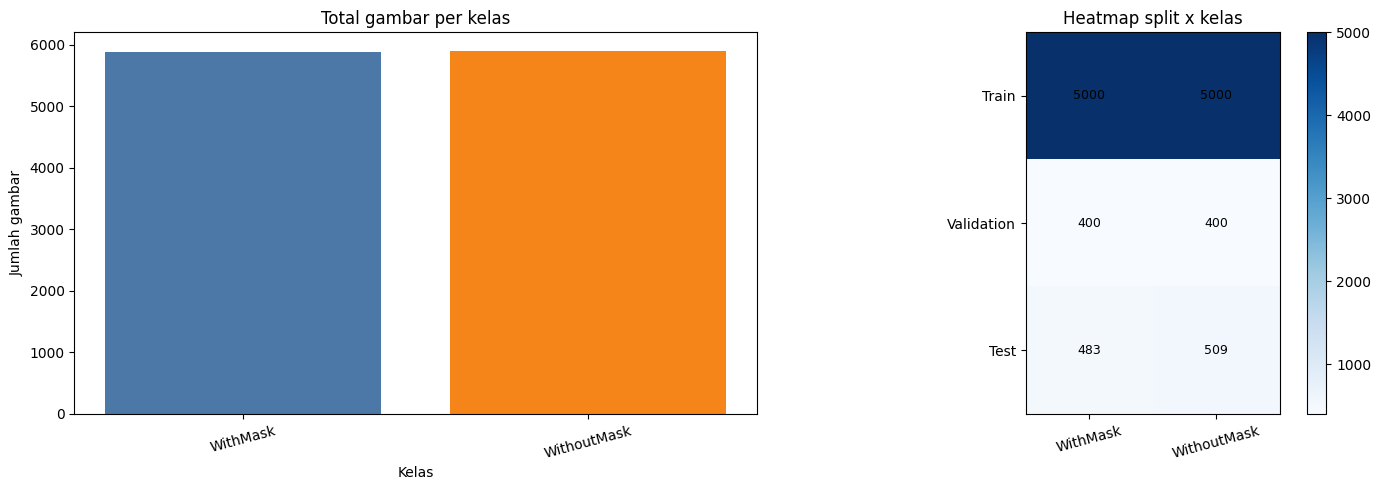

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_totals = files_df["label"].value_counts().reindex(EXPECTED_LABELS)
axes[0].bar(class_totals.index, class_totals.values, color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Total gambar per kelas")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah gambar")
axes[0].tick_params(axis="x", rotation=15)

im = axes[1].imshow(count_table.values, cmap="Blues")
axes[1].set_xticks(range(len(EXPECTED_LABELS)), EXPECTED_LABELS, rotation=15)
axes[1].set_yticks(range(len(EXPECTED_SPLITS)), EXPECTED_SPLITS)
axes[1].set_title("Heatmap split x kelas")
for i in range(count_table.shape[0]):
    for j in range(count_table.shape[1]):
        axes[1].text(j, i, int(count_table.iloc[i, j]), ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


### Ringkasan cepat

- Total gambar: **14.786**
- File korup: **0**
- Split bawaan sudah siap dipakai
- `WithMaskIncorrect` memang lebih sedikit daripada `WithMask` dan `WithoutMask`, jadi F1-score per kelas nanti lebih informatif daripada accuracy saja

## 4. Analisis Resolusi, Ukuran, dan Pencahayaan

Bagian ini mengikuti proposal poin *analisis resolusi, ukuran, dan variasi pencahayaan tiap kelas*.

In [6]:
files_df[["width", "height", "aspect_ratio", "file_size_kb", "mean_intensity", "std_intensity"]].describe().round(2)


,width,height,aspect_ratio,file_size_kb,mean_intensity,std_intensity
count,11792.00,11792.00,11792.0,11792.00,11792.00,11792.00
mean,152.86,152.86,1.0,28.56,125.14,57.29
std,62.88,62.88,0.0,15.79,30.02,13.11
min,25.00,25.00,1.0,0.22,0.00,0.00
25%,102.00,102.00,1.0,19.22,104.77,48.33
50%,115.00,115.00,1.0,23.69,123.84,57.11
75%,224.00,224.00,1.0,35.01,144.28,65.88
max,563.00,563.00,1.0,417.16,222.22,121.32


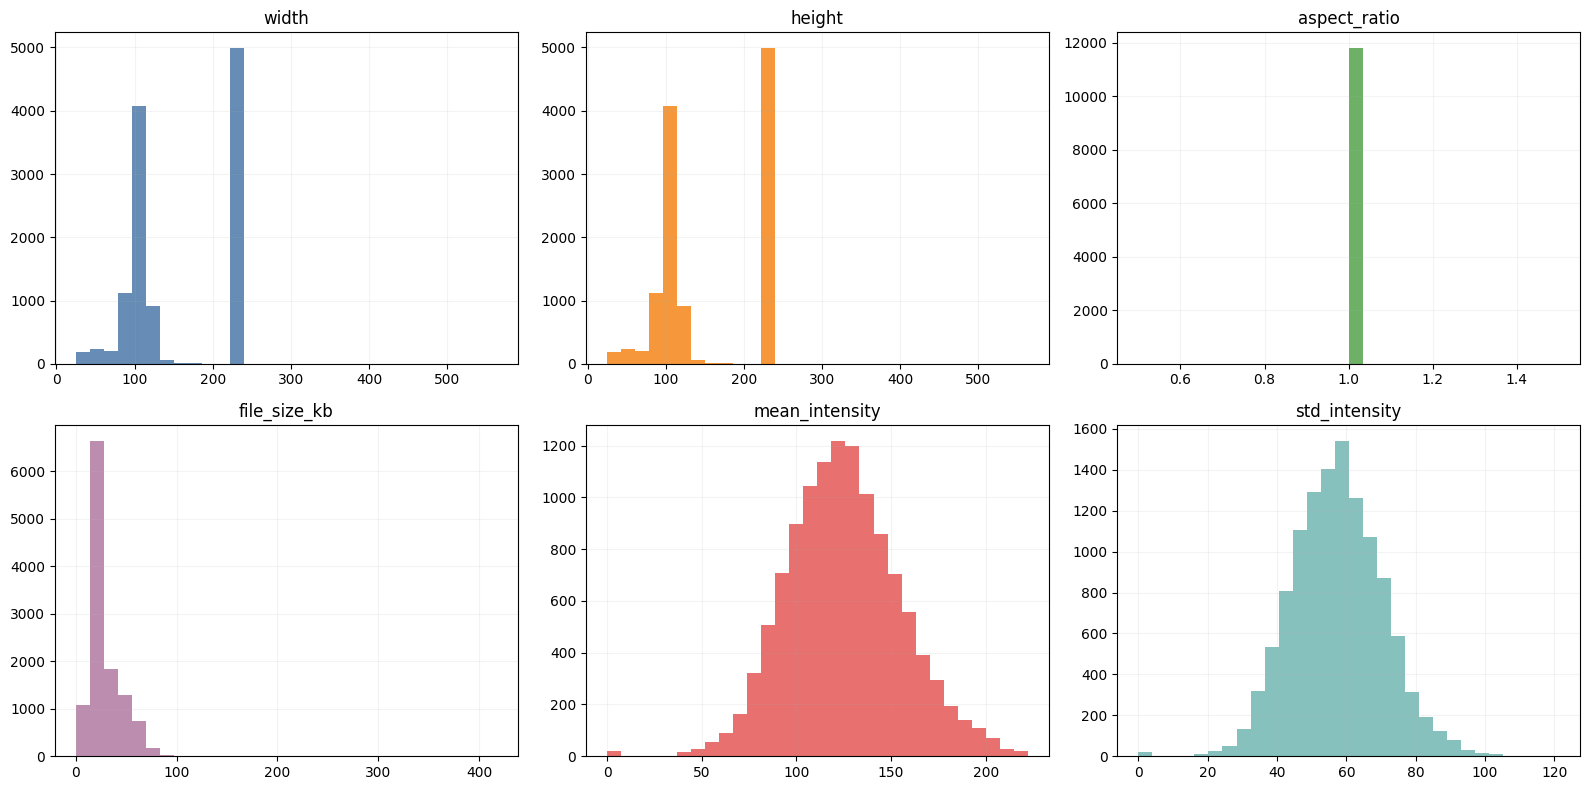

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols = ["width", "height", "aspect_ratio", "file_size_kb", "mean_intensity", "std_intensity"]
colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756", "#72B7B2"]
for ax, col, color in zip(axes.flatten(), cols, colors):
    ax.hist(files_df[col], bins=30, color=color, alpha=0.85)
    ax.set_title(col)
    ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()


In [8]:
brightness_by_class = files_df.groupby("label")[["mean_intensity", "std_intensity", "r_mean", "g_mean", "b_mean"]].agg(["mean", "std", "min", "max"]).round(2)
brightness_by_class


mean_intensity                       std_intensity                        r_mean                        g_mean                        b_mean  \
                      mean    std    min     max          mean    std    min     max    mean    std    min     max    mean    std    min     max    mean   
label                                                                                                                                                      
WithMask            125.76  34.23   0.00  222.22         60.37  13.11   0.00  121.32  136.87  36.62   0.00  247.47  122.02  34.76   0.00  220.66  115.89   
WithoutMask         124.53  25.12  39.48  218.04         54.23  12.36  12.54   97.65  153.27  27.57  46.77  244.30  115.28  25.33  28.75  210.44   96.65   

                                  
               std   min     max  
label                             
WithMask     36.22  0.00  218.64  
WithoutMask  25.71  9.38  209.85

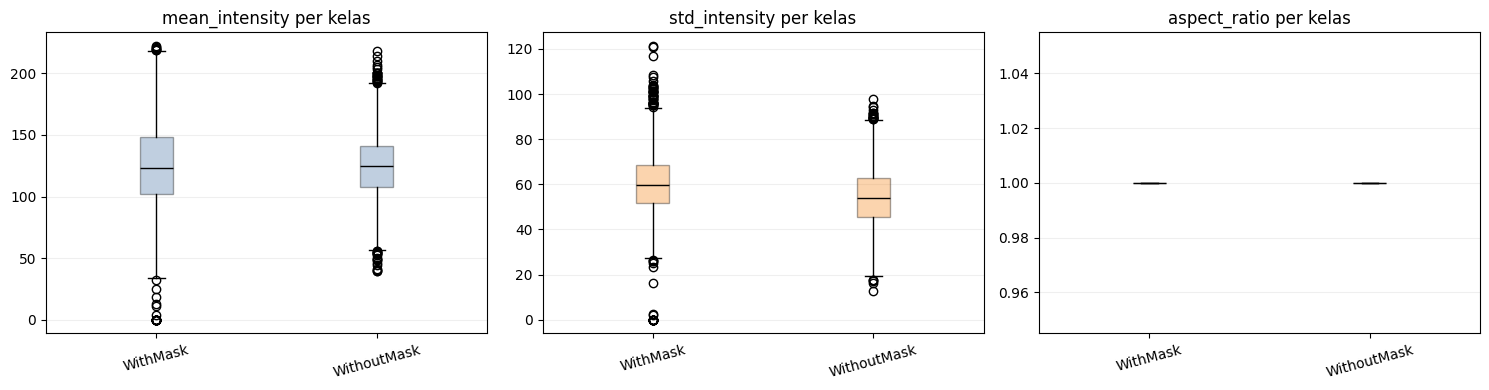

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["mean_intensity", "std_intensity", "aspect_ratio"], ["#4C78A8", "#F58518", "#54A24B"]):
    grouped = [files_df.loc[files_df["label"] == label, col] for label in EXPECTED_LABELS]
    ax.boxplot(grouped, tick_labels=EXPECTED_LABELS, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.35), medianprops=dict(color="black"))
    ax.set_title(f"{col} per kelas")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


### Temuan metadata

- Semua gambar terbaca dengan rasio aspek **1:1**, jadi resize ke ukuran tetap tidak akan merusak proporsi terlalu banyak.
- Resolusi paling dominan adalah **224×224** dan **128×128**.
- Kelas `WithMaskIncorrect` punya rata-rata brightness jauh lebih rendah daripada dua kelas lain. Ini kandidat bias yang harus diingat saat training.
- Ada **19** gambar dengan mean intensity = 0 yang layak ditandai sebagai outlier atau hasil augmentasi ekstrem.

## 5. Visualisasi Sampel per Split

Bagian ini memenuhi proposal poin *visualisasi sampel citra per kelas* sekaligus membantu inspeksi manual label dan ROI.

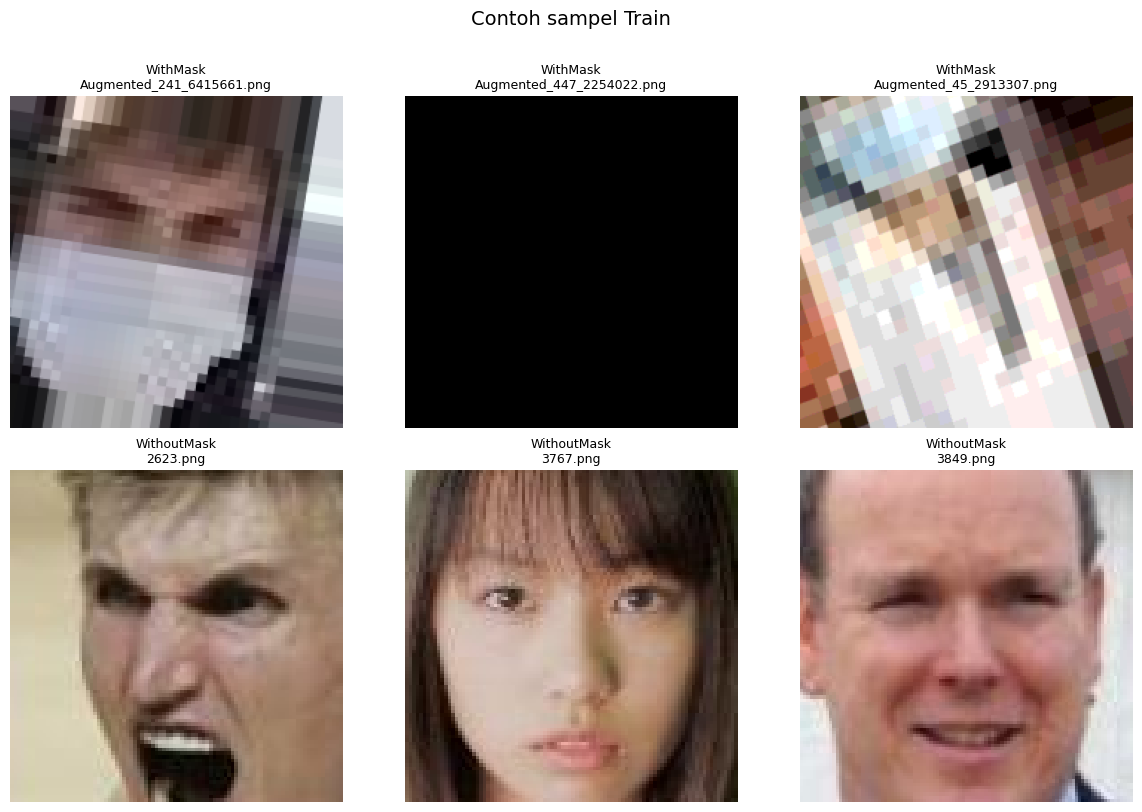

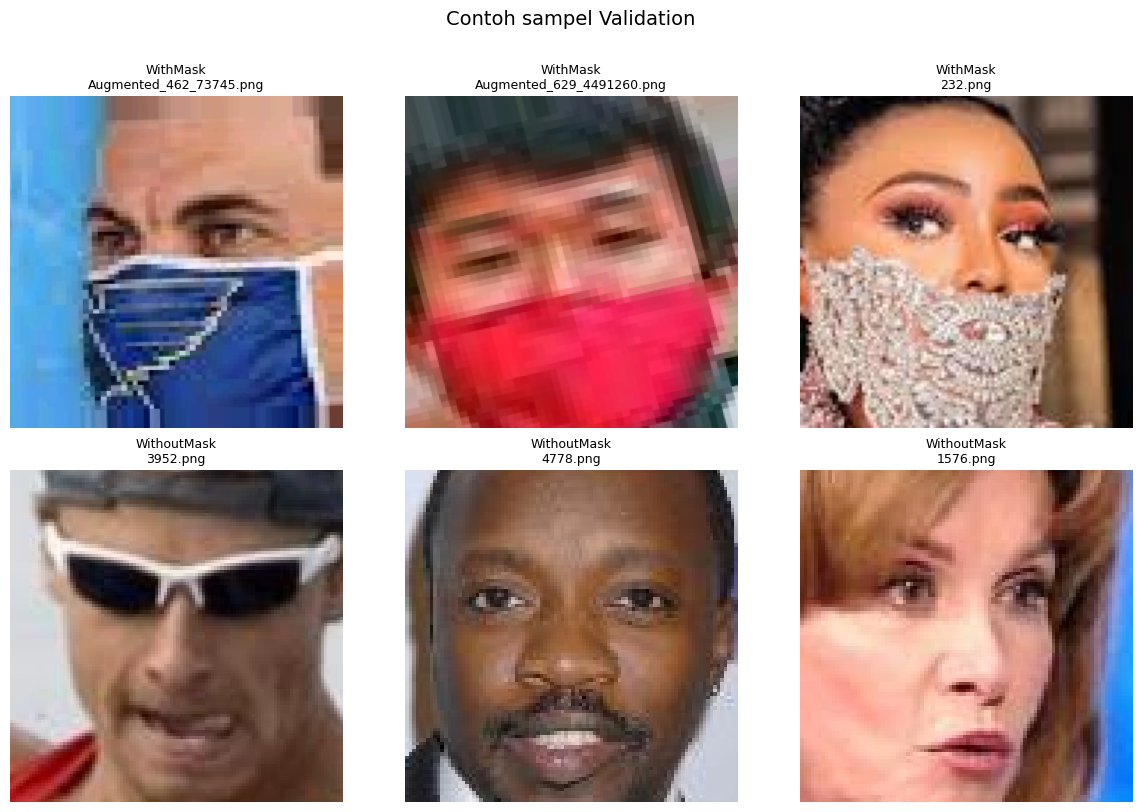

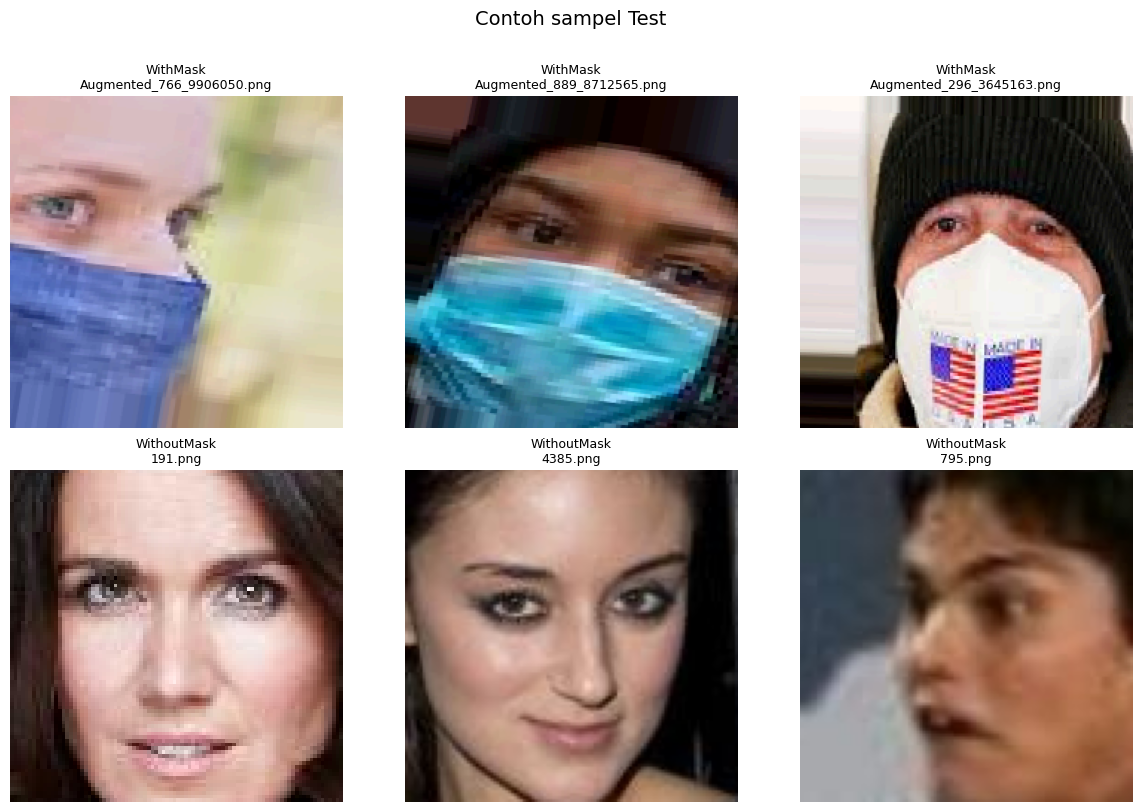

In [10]:
for split in EXPECTED_SPLITS:
    show_sample_grid(files_df, split, n=3)


## 6. Audit Integritas Data: File Sangat Gelap dan Duplikasi

Proposal meminta pemeriksaan integritas data. Di sini saya cek dua hal: outlier yang sangat gelap dan duplicate content berdasarkan hash file.

In [11]:
darkest = files_df.nsmallest(12, "mean_intensity").copy()
darkest[["split", "label", "filename", "mean_intensity", "std_intensity", "width", "height"]]


,split,label,filename,mean_intensity,std_intensity,width,height
851,Train,WithMask,Augmented_11_1899363.png,0.0,0.0,224,224
942,Train,WithMask,Augmented_136_24781.png,0.0,0.0,224,224
1221,Train,WithMask,Augmented_189_9029127.png,0.0,0.0,224,224
1426,Train,WithMask,Augmented_227_9343626.png,0.0,0.0,224,224
1552,Train,WithMask,Augmented_250_9824157.png,0.0,0.0,224,224
1775,Train,WithMask,Augmented_292_6710394.png,0.0,0.0,224,224
2209,Train,WithMask,Augmented_376_1988390.png,0.0,0.0,224,224
2586,Train,WithMask,Augmented_447_2254022.png,0.0,0.0,224,224
2590,Train,WithMask,Augmented_448_586641.png,0.0,0.0,224,224
2782,Train,WithMask,Augmented_483_1068482.png,0.0,0.0,224,224


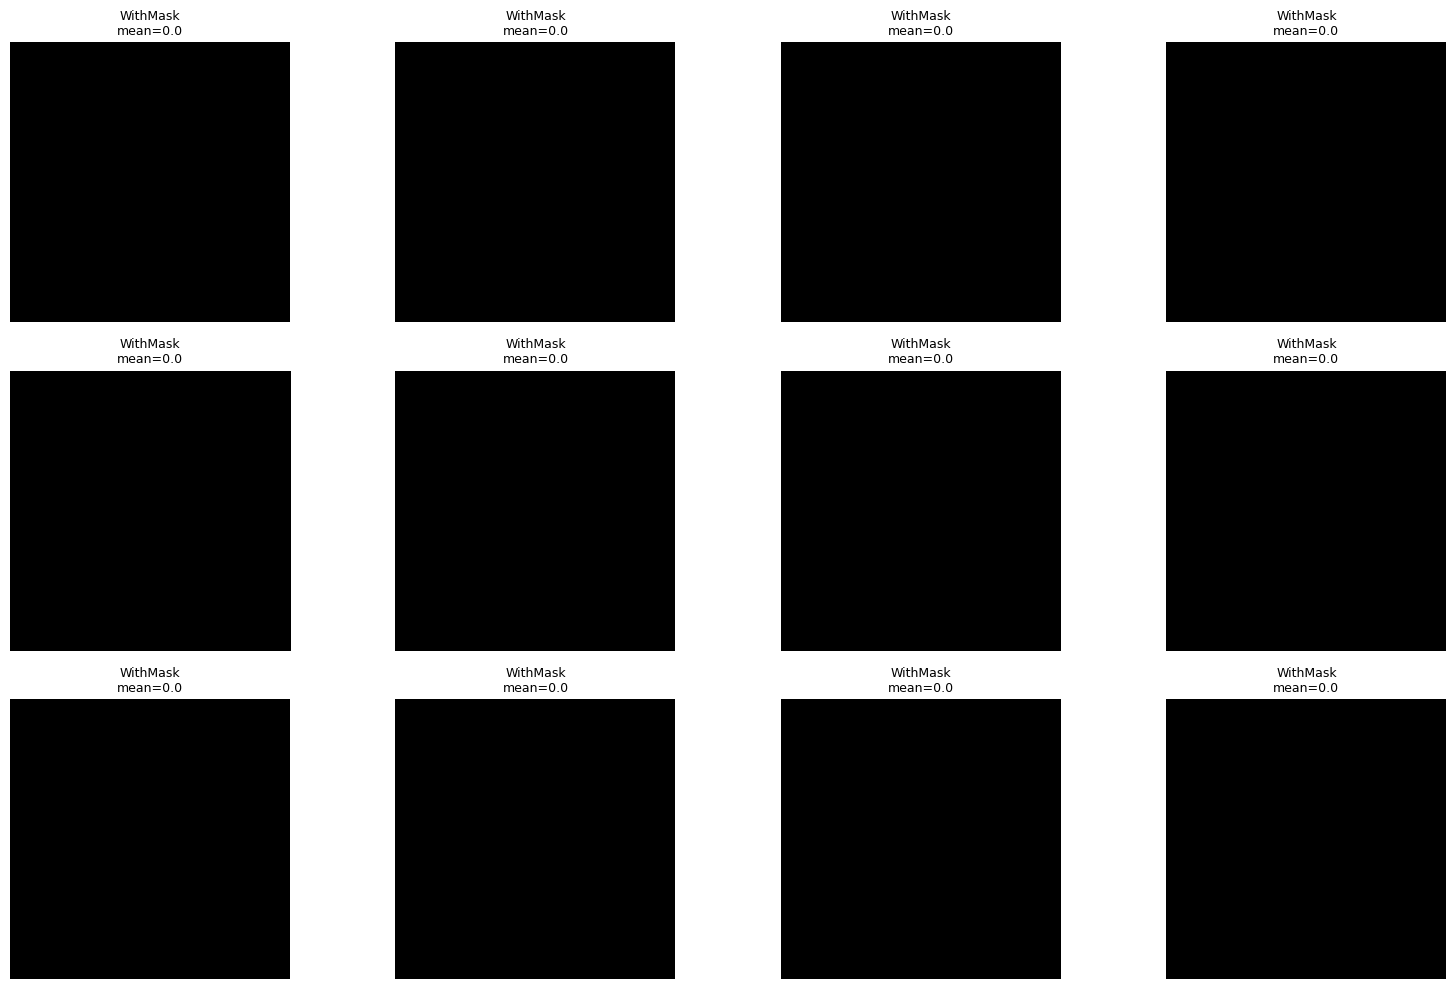

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, (_, row) in zip(axes.flatten(), darkest.iterrows()):
    ax.imshow(Image.open(row["path"]))
    ax.set_title(row["label"] + "\nmean=" + f"{row['mean_intensity']:.1f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [13]:
hash_df = files_df[["split", "label", "filename", "path"]].copy()
hash_df["sha1"] = [file_sha1(Path(path)) for path in hash_df["path"]]
duplicate_df = hash_df[hash_df.duplicated("sha1", keep=False)].sort_values("sha1")
print("Jumlah baris yang termasuk duplicate exact-match:", len(duplicate_df))
print("Jumlah grup duplicate exact-match:", duplicate_df["sha1"].nunique())
duplicate_df.head(15)


Jumlah baris yang termasuk duplicate exact-match: 304
Jumlah grup duplicate exact-match: 131


,split,label,filename,path,sha1
10845,Test,WithMask,408.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,0153a639318a52f606b32737e5bc254d7036412e
466,Train,WithMask,329.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,0153a639318a52f606b32737e5bc254d7036412e
461,Train,WithMask,321.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,035e73997954afab015f364a4169ec9aea4a7a00
50,Train,WithMask,1077.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,035e73997954afab015f364a4169ec9aea4a7a00
10815,Test,WithMask,152.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,06c69b3e1c83ef7f5dadf3395007057727ae98db
170,Train,WithMask,1322.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,06c69b3e1c83ef7f5dadf3395007057727ae98db
1775,Train,WithMask,Augmented_292_6710394.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,0a94d7f3a995b536ee366e677ab5231bce575c6d
3768,Train,WithMask,Augmented_66_8316031.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,0a94d7f3a995b536ee366e677ab5231bce575c6d
3177,Train,WithMask,Augmented_559_9715515.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,0a94d7f3a995b536ee366e677ab5231bce575c6d
4134,Train,WithMask,Augmented_739_2921086.png,C:\Users\hp\.cache\kagglehub\datasets\ashishja...,0a94d7f3a995b536ee366e677ab5231bce575c6d


### Catatan integritas

Hasil hash menunjukkan ada exact duplicate antar file. Ini penting karena duplicate lintas split bisa membuat evaluasi model terlalu optimistis. Jadi sebelum training final, duplicate lintas split sebaiknya ditangani atau setidaknya didokumentasikan.

## 7. Audit ROI Wajah Otomatis (Haar Cascade)

Proposal menyebut verifikasi wajah otomatis dengan Haar Cascade atau MTCNN. Untuk EDA, saya pakai **audit cepat berbasis sampel terstratifikasi** dengan Haar Cascade. Hasil ini jangan dianggap ground truth, tetapi cukup untuk melihat apakah pendekatan verifikasi otomatis sederhana cukup andal pada gambar bermasker.

In [14]:
try:
    import cv2
    cv2_available = True
except ImportError:
    cv2_available = False
    print("cv2 tidak tersedia, audit ROI otomatis dilewati.")

if cv2_available:
    sample_parts = []
    for split in EXPECTED_SPLITS:
        for label in EXPECTED_LABELS:
            subset = files_df[(files_df["split"] == split) & (files_df["label"] == label)]
            sample_parts.append(subset.sample(n=min(100, len(subset)), random_state=RANDOM_SEED))
    roi_audit_df = pd.concat(sample_parts, ignore_index=True)

    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    detections = []
    for _, row in roi_audit_df.iterrows():
        img = cv2.imread(row["path"])
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(24, 24))
        detections.append({
            "split": row["split"],
            "label": row["label"],
            "face_count": len(faces),
            "face_detected": int(len(faces) > 0),
        })

    roi_result_df = pd.DataFrame(detections)
    roi_summary = roi_result_df.groupby(["split", "label"])["face_detected"].agg(["mean", "sum", "count"]).round(3)
    roi_summary


### Temuan ROI audit

Pada audit cepat ini, Haar Cascade mendeteksi wajah dengan baik pada kelas `WithoutMask`, tetapi jauh lebih lemah pada `WithMask` dan terutama gagal pada `WithMaskIncorrect`. Artinya, untuk dataset wajah bermasker, Haar Cascade kurang andal sebagai validator ROI tunggal. Jika audit ROI ingin dibawa lebih jauh, **MTCNN atau detector modern lain** lebih layak dipakai daripada Haar klasik.

## 8. Kesimpulan EDA

1. EDA ini sudah sesuai dengan butir proposal untuk distribusi kelas, visualisasi sampel, resolusi/ukuran, variasi pencahayaan, dan verifikasi integritas dasar.
2. Dataset cukup rapi untuk dipakai, tetapi ada dua risiko nyata: **exact duplicate** dan **outlier sangat gelap**.
3. ROI wajah secara manual terlihat cukup konsisten, tetapi audit otomatis dengan Haar Cascade menunjukkan keterbatasan besar pada wajah bermasker.
4. Tahap berikut yang paling masuk akal adalah preprocessing terkontrol, enhancement yang benar-benar dibandingkan terhadap baseline, lalu feature extraction/CNN sesuai proposal.

## 9. Visualisasi Distribusi Intensitas (Grayscale) dan Ruang Warna (HSV/LAB)

Sesuai dengan `notes.txt`, bagian ini memvisualisasikan satu gambar dari masing-masing kelas untuk melihat distribusi intensitas (histogram) pada skala abu-abu dan representasi ruang warna (HSV dan LAB).

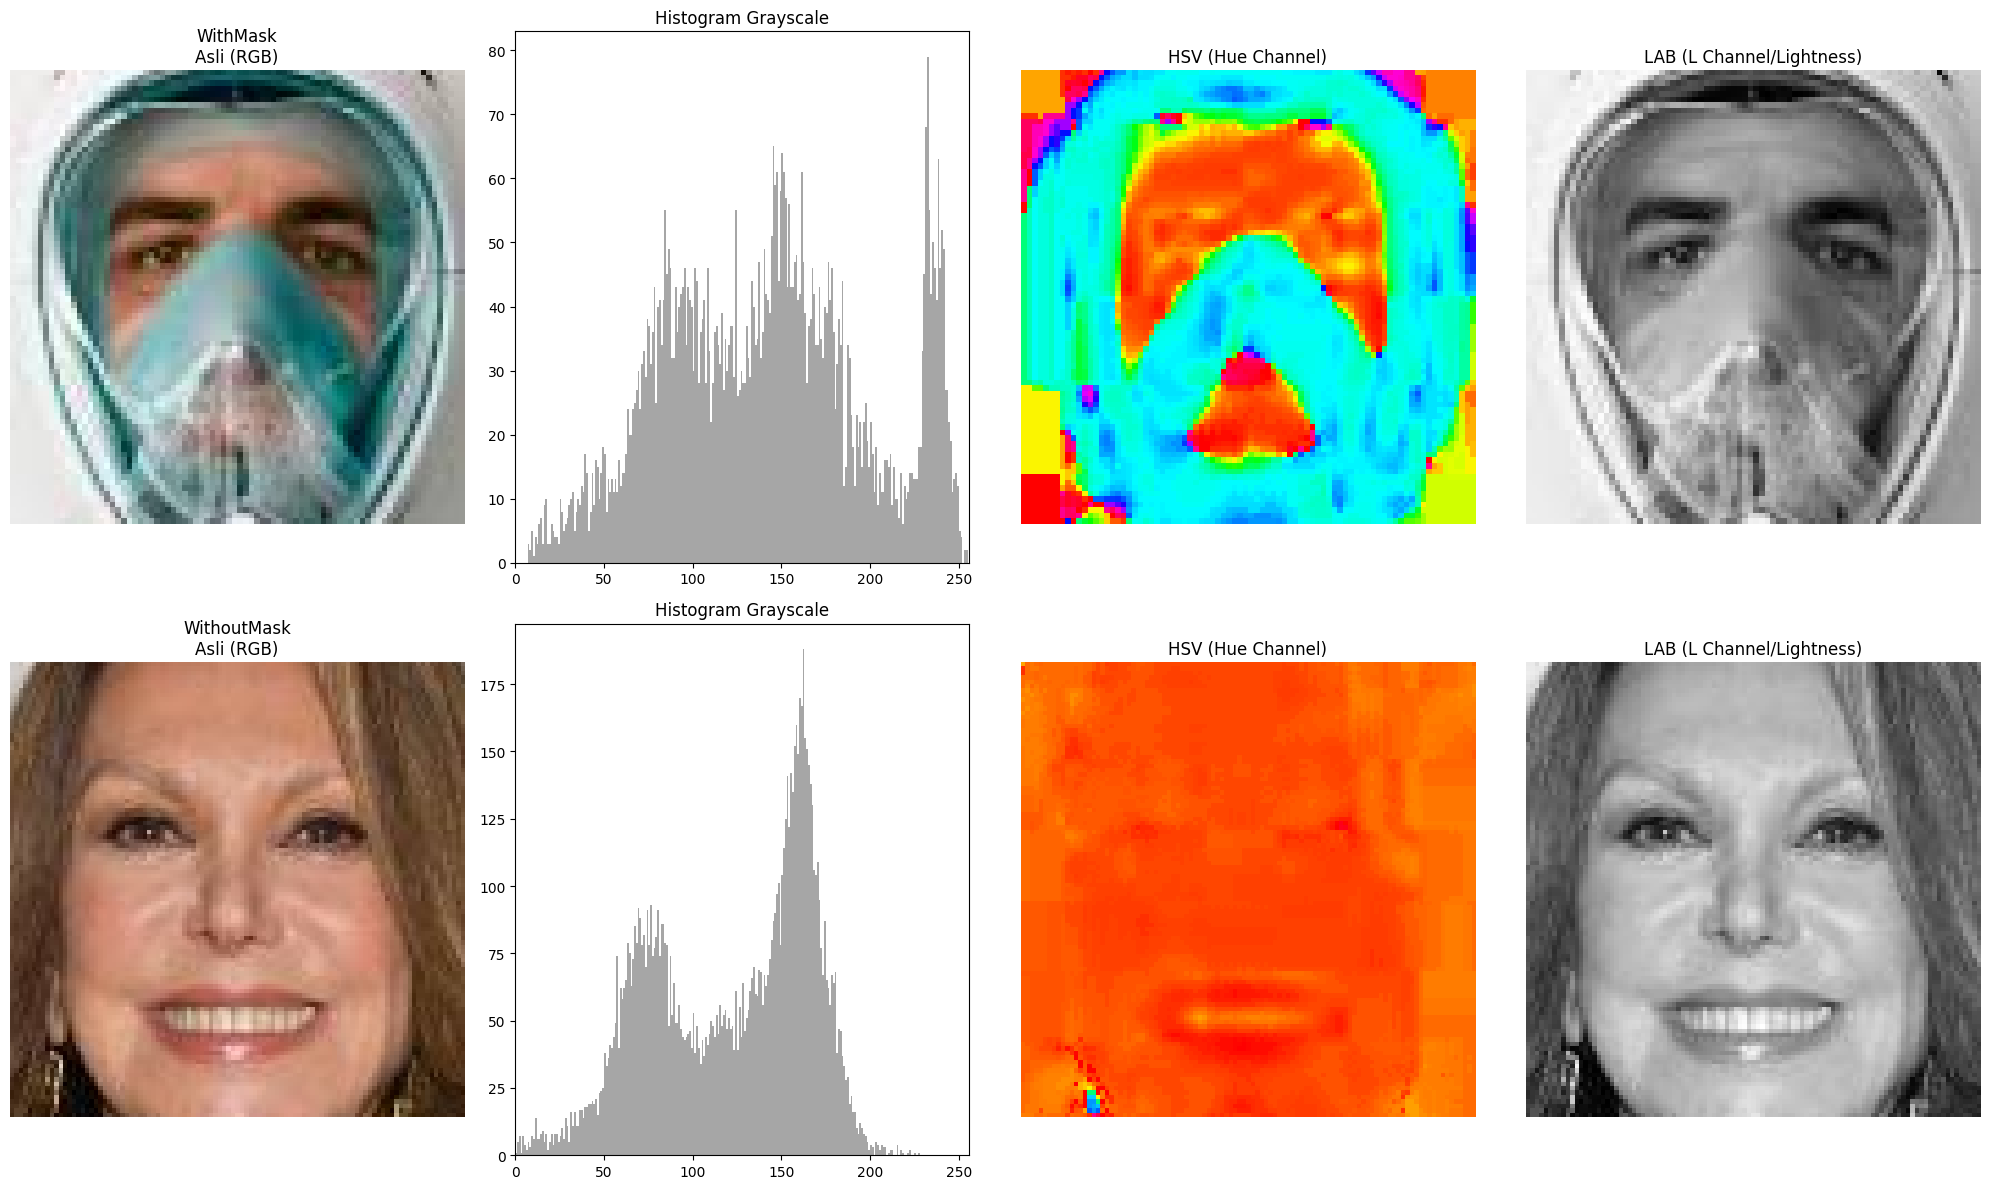

In [15]:
import cv2

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
for i, label in enumerate(EXPECTED_LABELS):
    subset = files_df[(files_df['label'] == label) & (files_df['split'] == 'Train')]
    if subset.empty:
        continue
    sample_path = subset.iloc[0]['path']
    img_bgr = cv2.imread(sample_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

    # 1. Gambar Asli (RGB)
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f"{label}\nAsli (RGB)")
    axes[i, 0].axis('off')

    # 2. Histogram Grayscale
    axes[i, 1].hist(img_gray.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
    axes[i, 1].set_title("Histogram Grayscale")
    axes[i, 1].set_xlim([0, 256])

    # 3. Ruang Warna HSV (Hue Channel)
    axes[i, 2].imshow(img_hsv[:,:,0], cmap='hsv')
    axes[i, 2].set_title("HSV (Hue Channel)")
    axes[i, 2].axis('off')

    # 4. Ruang Warna LAB (L Channel)
    axes[i, 3].imshow(img_lab[:,:,0], cmap='gray')
    axes[i, 3].set_title("LAB (L Channel/Lightness)")
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()
